<a href="https://colab.research.google.com/github/tejasarulmani/Operations-Labor-Capacity-Optimization-LP/blob/main/Operations_Labor_Capacity_Optimization_LP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase 1: Excel Interface Setup


In [62]:
import pandas as pd
import os

excel_file_name = 'Warehouse_Parameters.xlsx'

# Check if the file already exists (e.g., you uploaded a modified one)
if os.path.exists(excel_file_name):
    print(f"Loading existing business parameters from '{excel_file_name}'...")
    parameters_df = pd.read_excel(excel_file_name)

else:
    print(f"Creating default business parameters and saving to '{excel_file_name}'...")
    # Define default business parameters
    business_parameters = {
        'Parameter': [
            'Full-Time Wage ($/hr)',
            'Part-Time Wage ($/hr)',
            'Max Part-Time Ratio',
            'FT Shift Length (hours)',
            'PT Shift Length (hours)'
        ],
        'Value': [
            25,
            18,
            0.35,
            8,
            4
        ]
    }

    # Create a DataFrame and save to Excel
    parameters_df = pd.DataFrame(business_parameters)
    parameters_df.to_excel(excel_file_name, index=False)

# Display the active parameters DataFrame
display(parameters_df)

Creating default business parameters and saving to 'Warehouse_Parameters.xlsx'...


,Parameter,Value
0,Full-Time Wage ($/hr),25.00
1,Part-Time Wage ($/hr),18.00
2,Max Part-Time Ratio,0.35
3,FT Shift Length (hours),8.00
4,PT Shift Length (hours),4.00


## Phase 2: Synthetic Demand Engineering (EOQ Spikes)

In [63]:
import numpy as np
import pandas as pd

# Define simulation parameters
num_days = 14
blocks_per_day = 6

# Generate baseline staff demand for each block (between 5 and 10 workers)
# This creates a flat list of demand for all blocks across all days initially
baseline_demand = np.random.randint(5, 11, size=(num_days, blocks_per_day))

# Randomly select 4 days for 'EOQ Delivery Days'
eoq_delivery_days_indices = np.random.choice(num_days, 4, replace=False)

# Apply the demand spike of 250% for EOQ Delivery Days
for day_index in eoq_delivery_days_indices:
    baseline_demand[day_index, :] = np.ceil(baseline_demand[day_index, :] * 2.5)

# Prepare data for DataFrame
data = []
for day in range(num_days):
    for block in range(blocks_per_day):
        data.append({
            'Day': day + 1,
            'Block': block + 1,
            'Demand': int(baseline_demand[day, block])
        })

# Create the demand DataFrame
demand_df = pd.DataFrame(data)

# Display the first 18 rows (first 3 days)
display(demand_df.head(18))

,Day,Block,Demand
0,1,1,25
1,1,2,25
2,1,3,20
3,1,4,23
4,1,5,25
5,1,6,25
6,2,1,7
7,2,2,8
8,2,3,5
9,2,4,9


## Phase 3A: Mixed-Integer Linear Programming Engine (PuLP)

This model minimizes the total wage cost of staffing the warehouse while satisfying fluctuating demand and adhering to union/HR policies. It operates on **Shift Generation** (determining optimal shift start times and aggregate headcount) rather than Named Rostering.

**Decision Variables:**
* $F_t$ = Number of Full-Time shifts (8-hour, \$200/shift) starting at time block $t$.
* $P_t$ = Number of Part-Time shifts (4-hour, \$72/shift) starting at time block $t$.
* $D_t$ = Required staff demand for time block $t$.

**Objective Function (Minimize Total Wages):**
$$\min \sum_{t=1}^{84} (200 F_t + 72 P_t)$$

**Subject To:**
1. **Demand Satisfaction:** Active workers (FT starting now + FT continuing from last block + PT starting now) must meet or exceed required demand.
$$F_t + F_{t-1} + P_t \ge D_t \quad \forall t$$

2. **HR Part-Time Cap:** Part-time hours cannot exceed 35% of total hours worked.
$$\sum_{t=1}^{84} 4 P_t \le 0.35 \left( \sum_{t=1}^{84} (8 F_t + 4 P_t) \right)$$

3. **Integrality & Non-Negativity:** Shifts must be whole integers.
$$F_t, P_t \in \mathbb{Z}_{\ge 0} \quad \forall t$$

In [64]:
import pulp
import pandas as pd

# Force Python to read the saved Excel file instead of the Phase 1 memory
parameters_df = pd.read_excel('Warehouse_Parameters.xlsx')

# Get number of blocks from demand_df
num_blocks = len(demand_df)
# Assuming blocks_per_day is already defined from previous steps (6)
# If not, it can be retrieved from the original problem description or calculated.
# For robustness, let's ensure it's available or set a default.
if 'blocks_per_day' not in locals():
    blocks_per_day = 6 # Default as per problem description

# Initialize the problem
prob = pulp.LpProblem("Warehouse_Workforce_Optimization", pulp.LpMinimize)

# Create dictionaries of integer variables for FT and PT shifts
# These represent the number of shifts STARTING at each time block
FT = pulp.LpVariable.dicts("FT", range(num_blocks), lowBound=0, cat='Integer')
PT = pulp.LpVariable.dicts("PT", range(num_blocks), lowBound=0, cat='Integer')

# Retrieve parameters from the parameters_df DataFrame
# Ensure robust access to parameters_df values
def get_param_value(param_name):
    return parameters_df[parameters_df['Parameter'] == param_name]['Value'].iloc[0]

ft_wage_per_hour = get_param_value('Full-Time Wage ($/hr)')
pt_wage_per_hour = get_param_value('Part-Time Wage ($/hr)')
max_pt_ratio = get_param_value('Max Part-Time Ratio')
ft_shift_hours = get_param_value('FT Shift Length (hours)')
pt_shift_hours = get_param_value('PT Shift Length (hours)')

ft_wage_per_shift = ft_wage_per_hour * ft_shift_hours
pt_wage_per_shift = pt_wage_per_hour * pt_shift_hours

# Objective Function: Minimize total cost
prob += pulp.lpSum([ft_wage_per_shift * FT[t] + pt_wage_per_shift * PT[t] for t in range(num_blocks)]), "Total_Cost"

# Demand Constraint: Active workers must meet or exceed required demand
# An FT shift starting at 't' covers blocks 't' and 't+1' (8 hours = 2 blocks).
# A PT shift starting at 't' covers block 't' (4 hours = 1 block).
# So, for block 't', active workers are:
#   - FT shifts that started at 't' (FT[t])
#   - FT shifts that started at 't-1' (FT[t-1], if t is not the first block of a day)
#   - PT shifts that started at 't' (PT[t])
for t in range(num_blocks):
    required_staff = demand_df.loc[t, 'Demand']

    if t % blocks_per_day == 0: # First block of a day
        # No FT workers carry over from the previous day's last block
        prob += FT[t] + PT[t] >= required_staff, f"Demand_Constraint_Block_{t}"
    else:
        # FT workers from the previous block contribute
        prob += FT[t] + FT[t-1] + PT[t] >= required_staff, f"Demand_Constraint_Block_{t}"

# HR Policy Constraint: Part-time hours cannot exceed 35% of total hours worked
total_pt_hours = pulp.lpSum([PT[t] * pt_shift_hours for t in range(num_blocks)])
total_ft_hours = pulp.lpSum([FT[t] * ft_shift_hours for t in range(num_blocks)])
total_hours_worked = total_pt_hours + total_ft_hours

prob += total_pt_hours <= max_pt_ratio * total_hours_worked, "HR_Part_Time_Cap"

# Solve the model
prob.solve()

# Print the model status
print("Status:", pulp.LpStatus[prob.status])

# Print the optimal total cost
print("Optimal Total Cost = $", pulp.value(prob.objective))

# Extract the integer results into new columns in demand_df
demand_df['FT_Start'] = [FT[t].varValue if FT[t].varValue is not None else 0 for t in range(num_blocks)]
demand_df['PT_Start'] = [PT[t].varValue if PT[t].varValue is not None else 0 for t in range(num_blocks)]

# Calculate Total_Active workers for each block based on the optimized shifts
total_active_workers = []
for t in range(num_blocks):
    ft_current_start = demand_df.loc[t, 'FT_Start']

    # Determine FT workers carrying over from the previous block within the same day
    if t % blocks_per_day == 0: # First block of a day
        ft_previous_start = 0
    else:
        ft_previous_start = demand_df.loc[t-1, 'FT_Start']

    pt_current_start = demand_df.loc[t, 'PT_Start']

    active_at_block_t = ft_current_start + ft_previous_start + pt_current_start
    total_active_workers.append(active_at_block_t)

demand_df['Total_Active'] = total_active_workers
demand_df['Overstaffed_By'] = demand_df['Total_Active'] - demand_df['Demand']

# Display the first 18 rows of the updated demand_df
display(demand_df.head(18))

Status: Optimal
Optimal Total Cost = $ 86520.0


,Day,Block,Demand,FT_Start,PT_Start,Total_Active,Overstaffed_By
0,1,1,25,25.0,0.0,25.0,0.0
1,1,2,25,0.0,0.0,25.0,0.0
2,1,3,20,20.0,0.0,20.0,0.0
3,1,4,23,0.0,3.0,23.0,0.0
4,1,5,25,25.0,0.0,25.0,0.0
5,1,6,25,0.0,0.0,25.0,0.0
6,2,1,7,7.0,0.0,7.0,0.0
7,2,2,8,0.0,1.0,8.0,0.0
8,2,3,5,0.0,5.0,5.0,0.0
9,2,4,9,0.0,9.0,9.0,0.0


## Phase 3A: Graph

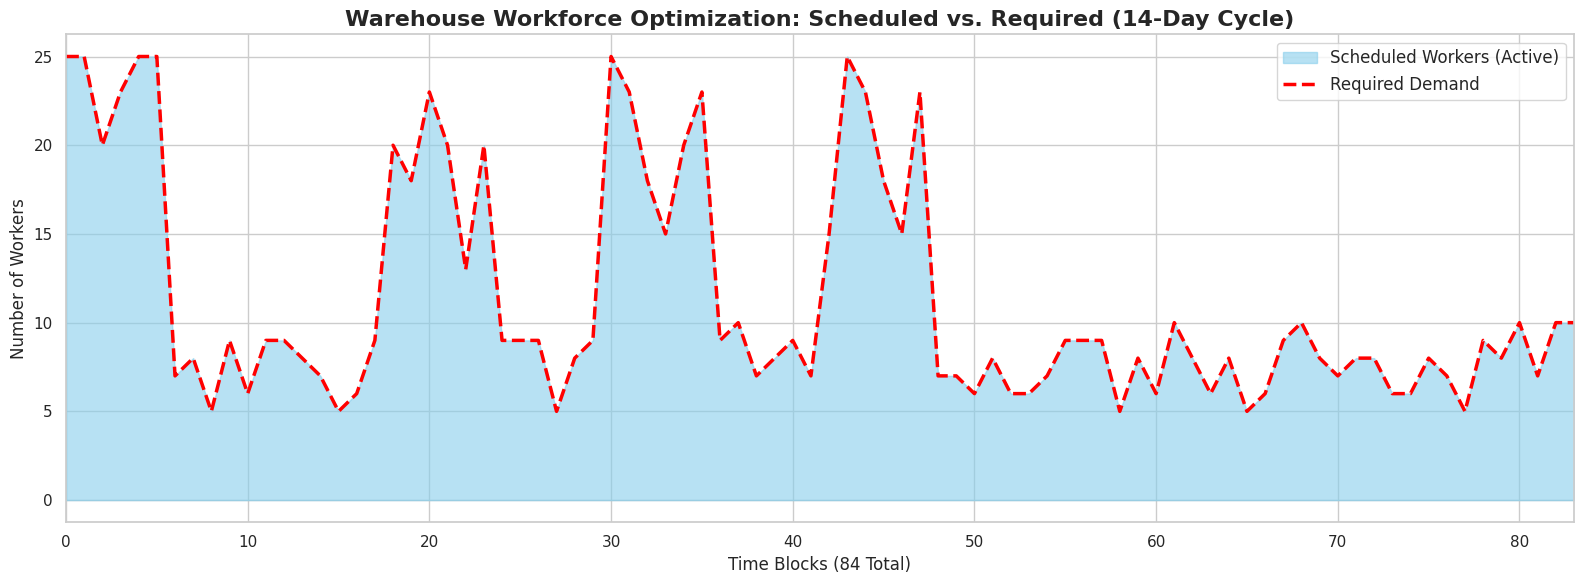

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(16, 6))

# Plot actual active scheduled workers as a shaded area
plt.fill_between(demand_df.index, demand_df['Total_Active'], color='skyblue', alpha=0.6, label='Scheduled Workers (Active)')

# Plot the required demand as a bold red dashed line
plt.plot(demand_df.index, demand_df['Demand'], color='red', linestyle='--', linewidth=2.5, label='Required Demand')

# Labels and formatting
plt.title('Warehouse Workforce Optimization: Scheduled vs. Required (14-Day Cycle)', fontsize=16, fontweight='bold')
plt.xlabel('Time Blocks (84 Total)', fontsize=12)
plt.ylabel('Number of Workers', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.xlim(0, num_blocks - 1)

# Display the graph
plt.tight_layout()
plt.savefig('coverage_chart.png', bbox_inches='tight')
plt.show()

## Phase 3B: Executive Summary & HR Handover (Headcount Planning)

While the optimization engine calculates the exact number of *shifts* needed per 4-hour block, human resources needs a macro-level view to execute hiring and payroll. This step translates the mathematical shift output into actionable business metrics, assuming standard labor contracts (10 shifts per 14-day cycle for both full-time and part-time staff).

In [66]:
import pandas as pd
import math

# Calculate total FT and PT shifts
total_ft_shifts = demand_df['FT_Start'].sum()
total_pt_shifts = demand_df['PT_Start'].sum()
total_shifts = total_ft_shifts + total_pt_shifts

# Calculate total costs separately
ft_total_cost = total_ft_shifts * ft_wage_per_shift
pt_total_cost = total_pt_shifts * pt_wage_per_shift
grand_total_cost = ft_total_cost + pt_total_cost

# Calculate required human headcount
ft_headcount = math.ceil(total_ft_shifts / 10)
pt_headcount = math.ceil(total_pt_shifts / 10)
total_headcount = ft_headcount + pt_headcount

# Build the summary data dictionary
summary_data = {
    'Metric': [
        'Total FT Shifts',
        'Total PT Shifts',
        'Total Shifts',
        'Total FT Wage Cost',
        'Total PT Wage Cost',
        'Grand Total Cost',
        'FT Headcount',
        'PT Headcount',
        'Total Headcount'
    ],
    'Value': [
        f"{total_ft_shifts:.0f}",
        f"{total_pt_shifts:.0f}",
        f"{total_shifts:.0f}",
        f"${ft_total_cost:,.2f}",
        f"${pt_total_cost:,.2f}",
        f"${grand_total_cost:,.2f}",
        f"{ft_headcount:.0f} workers",
        f"{pt_headcount:.0f} workers",
        f"{total_headcount:.0f} workers"
    ]
}

# Convert to DataFrame and display
executive_summary_df = pd.DataFrame(summary_data)
display(executive_summary_df)

,Metric,Value
0,Total FT Shifts,312
1,Total PT Shifts,335
2,Total Shifts,647
3,Total FT Wage Cost,"$62,400.00"
4,Total PT Wage Cost,"$24,120.00"
5,Grand Total Cost,"$86,520.00"
6,FT Headcount,32 workers
7,PT Headcount,34 workers
8,Total Headcount,66 workers


## Phase 3B: Graph

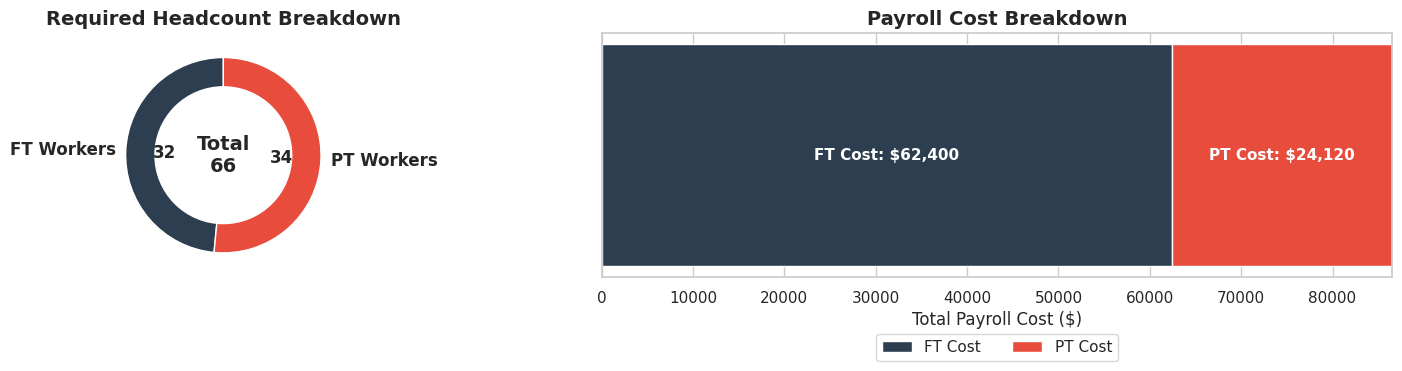

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
colors = ['#2c3e50', '#e74c3c']

# --- Chart 1: Headcount Donut Chart ---
ax1.pie([ft_headcount, pt_headcount], labels=['FT Workers', 'PT Workers'],
        colors=colors, autopct=lambda p: '{:.0f}'.format(p * total_headcount / 100),
        startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})

# Draw white circle in the middle to make it a donut
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax1.add_artist(centre_circle)
ax1.text(0, 0, f'Total\n{total_headcount}', ha='center', va='center', fontsize=14, fontweight='bold')
ax1.set_title('Required Headcount Breakdown', fontsize=14, fontweight='bold')

# --- Chart 2: Cost Horizontal Stacked Bar Chart ---
y_pos = [0]
# Plot the FT portion
ax2.barh(y_pos, ft_total_cost, color=colors[0], edgecolor='white', height=0.4, label='FT Cost')
# Plot the PT portion stacked next to it
ax2.barh(y_pos, pt_total_cost, left=ft_total_cost, color=colors[1], edgecolor='white', height=0.4, label='PT Cost')

# Add explicit text labels inside the bars
ax2.text(ft_total_cost / 2, 0, f'FT Cost: ${ft_total_cost:,.0f}',
         ha='center', va='center', color='white', fontsize=11, fontweight='bold')
ax2.text(ft_total_cost + (pt_total_cost / 2), 0, f'PT Cost: ${pt_total_cost:,.0f}',
         ha='center', va='center', color='white', fontsize=11, fontweight='bold')

# Formatting the stacked bar chart
ax2.set_yticks([])
ax2.set_xlabel('Total Payroll Cost ($)', fontsize=12)
ax2.set_title('Payroll Cost Breakdown', fontsize=14, fontweight='bold')
ax2.set_xlim(0, grand_total_cost)
ax2.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)

# Save the combined charts as an image file for Excel
plt.tight_layout()
plt.savefig('hr_charts.png', bbox_inches='tight')
plt.show()

## Phase 4: Automated Excel Dashboard Generation

This step represents the final stage of the data pipeline. The Python engine takes the optimized results and automatically generates a multi-sheet Excel workbook (`Optimized_Warehouse_Schedule.xlsx`) containing both the high-level HR summary and the granular daily schedule.

In [68]:
import pandas as pd
import os
from openpyxl.drawing.image import Image

output_file_name = 'Optimized_Warehouse_Schedule.xlsx'

with pd.ExcelWriter(output_file_name, engine='openpyxl') as writer:
    # Write executive_summary_df to 'HR_Summary' sheet
    executive_summary_df.to_excel(writer, sheet_name='HR_Summary', index=False)

    # Write demand_df to 'Optimized_Schedule' sheet
    demand_df.to_excel(writer, sheet_name='Optimized_Schedule', index=False)

    # Auto-adjust column widths for 'HR_Summary' sheet
    hr_summary_sheet = writer.sheets['HR_Summary']
    for column in hr_summary_sheet.columns:
        max_length = 0
        column_name = column[0].column_letter # Get the column name (e.g., 'A', 'B')
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = (max_length + 2) * 1.2 # Add a little padding
        hr_summary_sheet.column_dimensions[column_name].width = adjusted_width

    # Auto-adjust column widths for 'Optimized_Schedule' sheet
    optimized_schedule_sheet = writer.sheets['Optimized_Schedule']
    for column in optimized_schedule_sheet.columns:
        max_length = 0
        column_name = column[0].column_letter # Get the column name (e.g., 'A', 'B')
        for cell in column:
            try:
                if len(str(cell.value)) > max_length:
                    max_length = len(str(cell.value))
            except:
                pass
        adjusted_width = (max_length + 2) * 1.2 # Add a little padding
        optimized_schedule_sheet.column_dimensions[column_name].width = adjusted_width

    # --- Embed the Generated Charts ---

    # Place the HR Donut & Bar Charts on the Summary Sheet (Column D)
    if os.path.exists('hr_charts.png'):
        img_hr = Image('hr_charts.png')
        hr_summary_sheet.add_image(img_hr, 'D2')

    # Place the Coverage Area Graph on the Schedule Sheet (Column K)
    if os.path.exists('coverage_chart.png'):
        img_cov = Image('coverage_chart.png')
        optimized_schedule_sheet.add_image(img_cov, 'K2')

print(f"Excel file '{output_file_name}' generated successfully!")

Excel file 'Optimized_Warehouse_Schedule.xlsx' generated successfully!
